# Second Assignment: World Progress

**Name:** Denishay Mitchell Williams

This completed workbook uses pandas, NumPy, and matplotlib to explore global development data from Gapminder.

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots

## 1. Global Population Growth


The global population of humans reached 1 billion around 1800, 3 billion around 1960, and 7 billion around 2011. The potential impact of exponential population growth has concerned scientists, economists, and politicians alike.

The UN Population Division estimates that the world population will likely continue to grow throughout the 21st century, but at a slower rate, perhaps reaching 11 billion by 2100. However, the UN does not rule out scenarios of more extreme growth.

<a href="http://www.pewresearch.org/fact-tank/2015/06/08/scientists-more-worried-than-public-about-worlds-growing-population/ft_15-06-04_popcount/">
 <img src="https://www.pewresearch.org/wp-content/uploads/2015/06/fT_15.06.04_popCount.png"/>
</a>

In this section, we will examine some of the factors that influence population growth and how they are changing around the world.

The first table we will consider is the total population of each country over time. Run the cell below.

In [2]:
from pathlib import Path

DATA_URLS = {
    'population.csv': 'https://raw.githubusercontent.com/open-numbers/ddf--gapminder--gapminder_world/master/ddf--datapoints--population_total--by--geo--time.csv',
    'life_expectancy.csv': 'https://raw.githubusercontent.com/open-numbers/ddf--gapminder--gapminder_world/master/ddf--datapoints--life_expectancy_at_birth_with_projections--by--geo--time.csv',
    'child_mortality.csv': 'https://raw.githubusercontent.com/open-numbers/ddf--gapminder--gapminder_world/master/ddf--datapoints--child_mortality_0_5_year_olds_dying_per_1000_born--by--geo--time.csv',
    'fertility.csv': 'https://raw.githubusercontent.com/open-numbers/ddf--gapminder--gapminder_world/master/ddf--datapoints--children_per_woman_total_fertility--by--geo--time.csv',
    'countries.csv': 'https://raw.githubusercontent.com/open-numbers/ddf--gapminder--gapminder_world/master/ddf--entities--geo--country.csv',
    'poverty.csv': 'https://raw.githubusercontent.com/open-numbers/ddf--gapminder--gapminder_world/master/ddf--datapoints--extreme_poverty_percent_people_below_125_a_day--by--geo--time.csv',
}

COLUMN_RENAMES = {
    'life_expectancy_at_birth_with_projections': 'life_expectancy_years',
    'child_mortality_0_5_year_olds_dying_per_1000_born': 'child_mortality_under_5_per_1000_born',
    'extreme_poverty_percent_people_below_125_a_day': 'poverty_percent',
}

def load_dataset(filename: str) -> pd.DataFrame:
    """Load a course dataset locally first, then from Gapminder online if needed."""
    local_paths = [
        Path('../datasets') / filename,
        Path('datasets') / filename,
        Path(filename),
        Path('/mnt/data') / filename,  # useful when checking this notebook in ChatGPT/Python
    ]

    for path in local_paths:
        if path.exists():
            df = pd.read_csv(path)
            return df.rename(columns=COLUMN_RENAMES)

    df = pd.read_csv(DATA_URLS[filename])
    return df.rename(columns=COLUMN_RENAMES)

population = load_dataset('population.csv')
population.head(3)


,geo,population_total,time
0,afg,3280000,1800
1,afg,3280000,1810
2,afg,3324000,1820


### Bangladesh

In the `population` table, the `geo` column contains three-letter codes established by the [International Organization for Standardization](https://en.wikipedia.org/wiki/International_Organization_for_Standardization) (ISO) in the [Alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3#Current_codes) standard. We will begin by taking a close look at Bangladesh. Inspect the standard to find the 3-letter code for Bangladesh.

**Question 1.** Create a `DataFrame` called `b_pop` that has two columns labeled `time` and `population_total`. The first column should contain the years from 1970 through 2015 (including both 1970 and 2015) and the second should contain the population of Bangladesh in each of those years.

In [3]:
# Bangladesh uses the ISO Alpha-3 country code 'bgd'.
# This filters the population table to Bangladesh between 1970 and 2015.
b_pop = population[
    (population['geo'] == 'bgd') &
    (population['time'] >= 1970) &
    (population['time'] <= 2015)
][['time', 'population_total']]

b_pop

,time,population_total
1390,1970,65050000
1391,1971,66420000
1392,1972,67580000
1393,1973,68660000
1394,1974,69840000
1395,1975,71250000
1396,1976,72930000
1397,1977,74850000
1398,1978,76950000
1399,1979,79140000


Create a table called `b_five` that has the population of Bangladesh every five years. At a glance, it appears that the population of Bangladesh has been growing quickly indeed!

In [4]:
fives = np.arange(1970, 2016, 5) # 1970, 1975, 1980, ...

# Keep only the rows where the year is one of the five-year intervals.
b_five = b_pop[b_pop['time'].isin(fives)]

b_five

,time,population_total
1390,1970,65050000
1395,1975,71250000
1400,1980,81360000
1405,1985,93020000
1410,1990,106000000
1415,1995,118400000
1420,2000,131300000
1425,2005,142900000
1430,2010,151600000
1435,2015,161000000


**Question 2.** Create a table called `b_five_growth` that includes three columns, `time`, `population_total`, and `annual_growth`. There should be one row for every five years from 1970 through 2010 (but not 2015). The first two columns are the same as `b_five`. The third column is the **annual** growth rate for each five-year period. For example, the annual growth rate for 1975 is the yearly exponential growth rate that describes the total growth from 1975 to 1980 when applied 5 times.

*Hint*: Only your `b_five_growth` table will be scored for correctness; the other names are suggestions that you are welcome to use, change, or delete.

In [5]:
# Keep the starting years for each five-year growth period.
b_1970_through_2010 = b_five[b_five['time'] <= 2010].copy()

# Initial population at the start of each five-year period.
initial = b_1970_through_2010['population_total'].values

# Population five years later.
changed = b_five['population_total'].values[1:]

# Annual exponential growth rate over each five-year period.
annual_growth = (changed / initial) ** (1 / 5) - 1

b_five_growth = b_1970_through_2010.copy()
b_five_growth['annual_growth'] = annual_growth

b_five_growth

,time,population_total,annual_growth
1390,1970,65050000,0.018374
1395,1975,71250000,0.026893
1400,1980,81360000,0.027148
1405,1985,93020000,0.026469
1410,1990,106000000,0.022373
1415,1995,118400000,0.020899
1420,2000,131300000,0.017076
1425,2005,142900000,0.011890
1430,2010,151600000,0.012104


While the population has grown every five years since 1970, the annual growth rate decreased dramatically from 1985 to 2005. Let's look at some other information in order to develop a possible explanation. Run the next cell to load three additional tables of measurements about countries over time.

In [6]:
life_expectancy = load_dataset('life_expectancy.csv')
child_mortality = load_dataset('child_mortality.csv')
fertility = load_dataset('fertility.csv')


The `life_expectancy` table contains a statistic that is often used to measure how long people live, called *life expectancy at birth*. This number, for a country in a given year, [does not measure how long babies born in that year are expected to live](http://blogs.worldbank.org/opendata/what-does-life-expectancy-birth-really-mean). Instead, it measures how long someone would live, on average, if the *mortality conditions* in that year persisted throughout their lifetime. These "mortality conditions" describe what fraction of people at each age survived the year. So, it is a way of measuring the proportion of people that are staying alive, aggregated over different age groups in the population.

**Question 3.** Perhaps population is growing more slowly because people aren't living as long. Use the `life_expectancy` table to draw a line graph with the years 1970 and later on the horizontal axis that shows how the *life expectancy at birth* has changed in Bangladesh.

<Axes: title={'center': 'Life expectancy in Bangladesh from 1970 onwards'}, xlabel='time'>

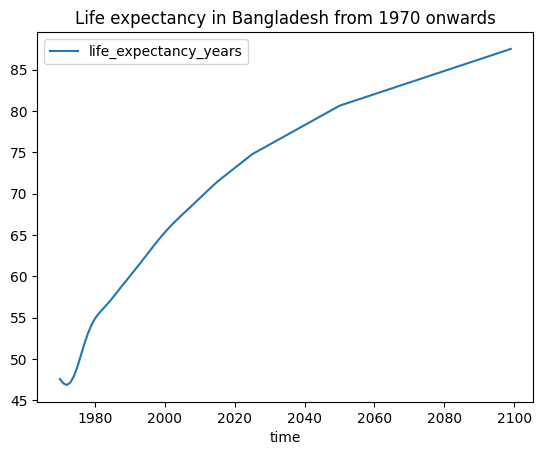

In [7]:
# Select Bangladesh from 1970 onwards and plot life expectancy over time.
bangladesh_life_expectancy = life_expectancy[
    (life_expectancy['geo'] == 'bgd') &
    (life_expectancy['time'] >= 1970)
]

bangladesh_life_expectancy.plot(
    x='time',
    y='life_expectancy_years',
    title='Life expectancy in Bangladesh from 1970 onwards'
)

Does the graph above help directly explain why the population growth rate decreased from 1985 to 2010 in Bangladesh? Why or why not? What happened in Bangladesh in 1991, and does that event explain the change in population growth rate?

No. The graph does not directly explain why Bangladesh's population growth rate decreased from 1985 to 2010, because life expectancy generally increased over this period. If people are living longer, that would not by itself explain slower population growth.

In 1991, Bangladesh experienced a major cyclone. This may have caused a short-term loss of life, but it does not explain the longer-term decline in annual population growth across several decades.

The `fertility` table contains a statistic that is often used to measure how many babies are being born, the *total fertility rate*. This number describes the [number of children a woman would have in her lifetime](https://www.measureevaluation.org/prh/rh_indicators/specific/fertility/total-fertility-rate), on average, if the current rates of birth by age of the mother persisted throughout her child bearing years, assuming she survived through age 49.

**Question 4.** Write a function `fertility_over_time` that takes the Alpha-3 code of a `country` and a `start` year. It returns a two-column table with labels "`Year`" and "`Children per woman`" that can be used to generate a line chart of the country's fertility rate each year, starting at the `start` year. The plot should include the `start` year and all later years that appear in the `fertility` table.

Then, in the next cell, call your `fertility_over_time` function on the Alpha-3 code for Bangladesh and the year 1970 in order to plot how Bangladesh's fertility rate has changed since 1970. **The expression that draws the line plot is provided for you; please don't change it.**

In [8]:
def fertility_over_time(country: str, start: int) -> pd.DataFrame:
    """
    Create a two-column DataFrame that describes a country's total fertility rate each year.
    :param country - alpha-3 code for the country
    :param start - start year
    """
    data = fertility[
        (fertility['geo'] == country) &
        (fertility['time'] >= start)
    ][['time', 'children_per_woman_total_fertility']]

    data = data.rename(columns={
        'time': 'Year',
        'children_per_woman_total_fertility': 'Children per woman'
    })

    return data

<Axes: xlabel='Year'>

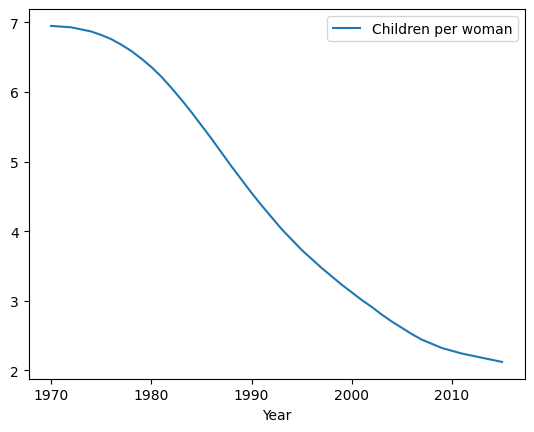

In [9]:
bangladesh_code = fertility_over_time('bgd', 1970)
bangladesh_code.plot(0, 1) # You should *not* change this line.

**Question 5.** Does the graph above help directly explain why the population growth rate decreased from 1985 to 2010 in Bangladesh? Why or why not?

Yes. The fertility graph helps explain the decrease in population growth because it shows that the number of children per woman in Bangladesh fell substantially after 1970.

This decline in fertility means fewer births, which directly contributes to slower population growth even while life expectancy is increasing.

It has been observed that lower fertility rates are often associated with lower child mortality rates. The link has been attributed to family planning: if parents can expect that their children will all survive into adulthood, then they will choose to have fewer children. We can see if this association is evident in Bangladesh by plotting the relationship between total fertility rate and [child mortality rate per 1000 children](https://en.wikipedia.org/wiki/Child_mortality).

**Question 6.** Using both the `fertility` and `child_mortality` tables, draw a scatter diagram with one point for each year, starting with 1970, that has Bangladesh's total fertility on the horizontal axis and its child mortality on the vertical axis.

**The expression that draws the scatter diagram is provided for you; please don't change it.** Instead, create a table called `fertility_and_child_mortality` with the appropriate column labels and data in order to generate the chart correctly. Use the label "`Children per woman`" to describe total fertility and the label "`Child deaths per 1000 born`" to describe child mortality.

<Axes: xlabel='Children per woman', ylabel='Child deaths per 1000 born'>

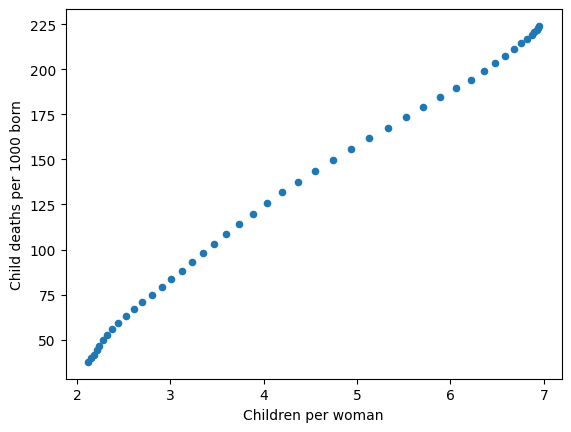

In [10]:
# Select Bangladesh fertility values from 1970 onwards.
bangladesh_fertility = fertility[
    (fertility['geo'] == 'bgd') &
    (fertility['time'] >= 1970)
][['geo', 'time', 'children_per_woman_total_fertility']]

# Select Bangladesh child mortality values from 1970 onwards.
bangladesh_child_mortality = child_mortality[
    (child_mortality['geo'] == 'bgd') &
    (child_mortality['time'] >= 1970)
][['geo', 'time', 'child_mortality_under_5_per_1000_born']]

# Merge the two tables so that each year has both fertility and child mortality.
fertility_and_child_mortality = pd.merge(
    bangladesh_fertility,
    bangladesh_child_mortality,
    on=['geo', 'time']
)

fertility_and_child_mortality = fertility_and_child_mortality.rename(columns={
    'children_per_woman_total_fertility': 'Children per woman',
    'child_mortality_under_5_per_1000_born': 'Child deaths per 1000 born'
})

fertility_and_child_mortality = fertility_and_child_mortality[
    ['Children per woman', 'Child deaths per 1000 born']
]

# You should *not* change the statement below
fertility_and_child_mortality.plot.scatter(
    'Children per woman', 'Child deaths per 1000 born'
)

In one or two sentences, describe the association (if any) that is illustrated by this scatter diagram. Does the diagram show that reduced child mortality causes parents to choose to have fewer children?

The scatter diagram shows a positive association: years with higher child mortality also tend to have higher fertility, while years with lower child mortality tend to have lower fertility.

However, the diagram does not prove that reduced child mortality causes parents to have fewer children. It shows an association, not causation.

### The World

The change observed in Bangladesh since 1970 can also be observed in many other developing countries: health services improve, life expectancy increases, and child mortality decreases. At the same time, the fertility rate often plummets, and so the population growth rate decreases despite increasing longevity.

Run the cell below to generate two overlaid histograms, one for 1960 and one for 2010, that show the distributions of total fertility rates for these two years among all 201 countries in the `fertility` table.

In [11]:
fertility[fertility.time == 1960]


,geo,children_per_woman_total_fertility,time
160,afg,7.67,1960
376,alb,6.19,1960
592,dza,7.65,1960
808,ago,7.32,1960
1024,atg,4.43,1960
...,...,...,...
42492,vnm,6.35,1960
42708,vir,5.62,1960
42924,yem,7.29,1960
43140,zmb,7.02,1960


In [12]:
fertility[fertility.time == 1960].iloc[:, [0, 2]].set_index("geo")

,time
geo,
afg,1960
alb,1960
dza,1960
ago,1960
atg,1960
...,...
vnm,1960
vir,1960
yem,1960


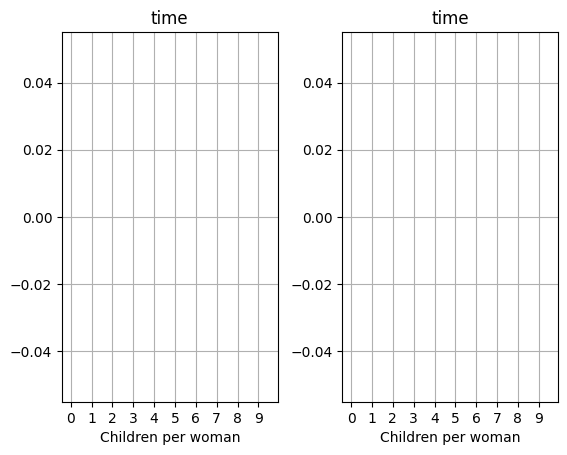

In [13]:
ax = pd.concat([
    fertility[fertility.time == 1960].iloc[:, [0, 2]].rename(
        columns={"children_per_woman_total_fertility": "1960"}
    ).set_index("geo"),
    fertility[fertility.time == 2010].iloc[:, [0, 2]].rename(
        columns={"children_per_woman_total_fertility": "2010"}
    ).set_index("geo")
], axis=1).hist(bins=np.arange(0, 10, 0.5))
for ix in range(len(ax[0])):
    ax[0][ix].set_xlabel('Children per woman')
    ax[0][ix].set_xticks(np.arange(10))

**Question 7.** Assign `fertility_statements` to a list of the numbers for each statement below that can be correctly inferred from these histograms.
1. About the same number of countries had a fertility rate between 3.5 and 4.5 in both 1960 and 2010.
1. In 2010, about 40% of countries had a fertility rate between 1.5 and 2.
1. In 1960, less than 20% of countries had a fertility rate below 3.
1. More countries had a fertility rate above 3 in 1960 than in 2010.
1. At least half of countries had a fertility rate between 5 and 8 in 1960.
1. At least half of countries had a fertility rate below 3 in 2010.

In [14]:
# Statements that can be inferred from the histograms.
fertility_statements = [2, 3, 4, 6]

fertility_statements

[2, 3, 4, 6]

**Question 8.** Draw a line plot of the world population from 1800 through 2005. The world population is the sum of all the country's populations.

<Axes: title={'center': 'World population from 1800 to 2005'}, xlabel='time'>

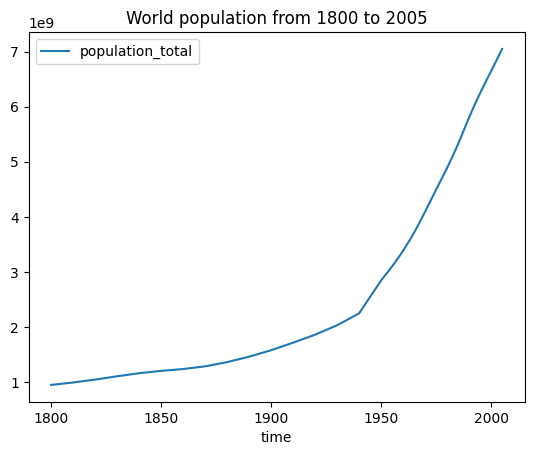

In [15]:
# Sum each country's population for every year, then keep the requested period.
world_population = population.groupby('time')['population_total'].sum().reset_index()
world_population = world_population[
    (world_population['time'] >= 1800) &
    (world_population['time'] <= 2005)
]

world_population.plot(
    x='time',
    y='population_total',
    title='World population from 1800 to 2005'
)

**Question 9.** Create a function `stats_for_year` that takes a `year` and returns a table of statistics. The table it returns should have four columns: `geo`, `population_total`, `children_per_woman_total_fertility`, and `child_mortality_under_5_per_1000_born`. Each row should contain one Alpha-3 country code and three statistics: population, fertility rate, and child mortality for that `year` from the `population`, `fertility` and `child_mortality` tables. Only include rows for which all three statistics are available for the country and year.

In addition, restrict the result to country codes that appears in `big_50`, an array of the 50 most populous countries in 2010. This restriction will speed up computations later in the project.

In [16]:
big_50 = population[(population["time"] == 2010)].sort_values(
    by="population_total", ascending=False
).head(50)
population_of_big_50 = big_50.population_total
big_50.sample(5)

,geo,population_total,time
6022,fra,62960000,2010
17355,tha,66690000,2010
14483,rus,143200000,2010
17922,tur,72310000,2010
11383,mex,118600000,2010


In [17]:
# We first create a population table that only includes the
# 50 countries with the largest 2010 populations. We focus on
# these 50 countries only so that plotting later will run faster.

big_50_codes = big_50['geo']

def stats_for_year(year: int) -> pd.DataFrame:
    """
    Return a DataFrame with population, fertility, and child mortality
    for the 50 largest countries in 2010, for a selected year.
    """
    pop_year = population[population['time'] == year][['geo', 'population_total']]
    fertility_year = fertility[fertility['time'] == year][[
        'geo',
        'children_per_woman_total_fertility'
    ]]
    mortality_year = child_mortality[child_mortality['time'] == year][[
        'geo',
        'child_mortality_under_5_per_1000_born'
    ]]

    combined = pop_year.merge(fertility_year, on='geo')
    combined = combined.merge(mortality_year, on='geo')

    combined = combined[combined['geo'].isin(big_50_codes)]

    return combined[[
        'geo',
        'population_total',
        'children_per_woman_total_fertility',
        'child_mortality_under_5_per_1000_born'
    ]]

In [18]:
# You should verify the function you have written is correct
# by running this cell for year 2010
stats_for_year(2010)


,geo,population_total,children_per_woman_total_fertility,child_mortality_under_5_per_1000_born
0,afg,27960000,5.66,105.0
2,dza,36040000,2.82,27.4
5,arg,41220000,2.22,14.6
13,bgd,151600000,2.28,49.6
23,bra,198600000,1.84,16.7
30,can,34130000,1.63,5.6
36,chn,1341000000,1.54,15.7
37,col,45920000,2.38,18.5
39,cod,65940000,6.25,116.1
51,egy,82040000,2.88,29.0


**Question 10.** Create a table called `pop_by_decade` with two columns called `decade` and `population`. It has a row for each `year` since 1960 that starts a decade. The `population` column contains the total population of all countries included in the result of `stats_for_year(year)` for the first `year` of the decade. For example, 1960 is the first year of the 1960's decade. You should see that these countries contain most of the world's population.

*Hint:* One approach is to define a function `pop_for_year` that computes this total population, then `apply` it to the `decade` column.

In [19]:
decades = pd.DataFrame({
    'decade': np.arange(1960, 2011, 10)
    }
)

def pop_for_year(year):
    return stats_for_year(year)['population_total'].sum()

pop_by_decade = decades.copy()
pop_by_decade['population'] = pop_by_decade['decade'].apply(pop_for_year)

pop_by_decade

,decade,population
0,1960,2625070000
1,1970,3211355000
2,1980,3880702000
3,1990,4648740000
4,2000,5367140000
5,2010,6040780000


The `countries` table describes various characteristics of countries. The `country` column contains the same codes as the `geo` column in each of the other data tables (`population`, `fertility`, and `child_mortality`). The `world_6region` column classifies each country into a region of the world. Run the cell below to inspect the data.

In [20]:
countries = load_dataset('countries.csv')
if 'world_6region' not in countries.columns:
    countries['world_6region'] = countries.get('geographic_regions')
countries[['country', 'name', 'world_6region']]


,country,name,world_6region
0,abkh,Abkhazia,europe_central_asia
1,afg,Afghanistan,south_asia
2,akr_a_dhe,Akrotiri and Dhekelia,europe_central_asia
3,alb,Albania,europe_central_asia
4,dza,Algeria,middle_east_north_africa
...,...,...,...
270,yem,Yemen,middle_east_north_africa
271,yug,Yugoslavia,europe_central_asia
272,zmb,Zambia,sub_saharan_africa
273,zwe,Zimbabwe,sub_saharan_africa


## 2. Global Poverty


In 1800, 85% of the world's 1 billion people lived in *extreme poverty*, defined by the United Nations as "a condition characterized by severe deprivation of basic human needs, including food, safe drinking water, sanitation facilities, health, shelter, education and information." A common measure of extreme poverty is a person living on less than \$1.25 per day.

In 2015, the proportion of people living in extreme poverty was estimated to be 12%. Although the world rate of extreme poverty has declined consistently for hundreds of years, the number of people living in extreme poverty is still close to 1 billion. The United Nations recently adopted an [ambitious goal](http://www.un.org/sustainabledevelopment/poverty/): "By 2030, eradicate extreme poverty for all people everywhere."
In this section, we will examine extreme poverty trends around the world.

First, load the population and poverty rate by country and year and the country descriptions. While the `population` table has values for every recent year for many countries, the `poverty` table only includes certain years for each country in which a measurement of the rate of extreme poverty was available.

In [21]:
population = load_dataset('population.csv')
population.head(5)


,geo,population_total,time
0,afg,3280000,1800
1,afg,3280000,1810
2,afg,3324000,1820
3,afg,3449000,1830
4,afg,3625000,1840


In [22]:
countries = load_dataset('countries.csv')
if 'world_6region' not in countries.columns:
    countries['world_6region'] = countries.get('geographic_regions')
countries = countries[countries['country'].isin(population.geo.unique())]
countries.info()


<class 'pandas.core.frame.DataFrame'>
Index: 255 entries, 1 to 274
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         255 non-null    object 
 1   gwid                            255 non-null    object 
 2   name                            255 non-null    object 
 3   geographic_regions              253 non-null    object 
 4   income_groups                   214 non-null    object 
 5   landlocked                      253 non-null    object 
 6   g77_and_oecd_countries          252 non-null    object 
 7   geographic_regions_in_4_colors  252 non-null    object 
 8   main_religion_2008              215 non-null    object 
 9   gapminder_list                  253 non-null    object 
 10  alternative_1                   68 non-null     object 
 11  alternative_2                   36 non-null     object 
 12  alternative_3                   21 non-nu

In [23]:
poverty = load_dataset('poverty.csv')
poverty.sample(3)


,geo,poverty_percent,time
238,col,9.01,2004
953,swe,0.35,2005
823,phl,23.70,1997


**Question 11.** Assign `latest` to a three-column table with one row for each country that appears in the `poverty` table. The first column should contain the 3-letter code for the country. The second column should contain the *most recent year* for which an extreme poverty rate is available for the country. The third column should contain the poverty rate in that year. **Do not change the last line, so that the labels of your table are set correctly.**

*Hint*: the `first` function may be helpful, but you are not required to use it.

In [24]:
def first(values):
    return values.iloc[0]

# Sort by country and year so that the most recent poverty value is kept for each country.
latest = poverty.sort_values(['geo', 'time']).groupby('geo').tail(1)

latest = latest[['geo', 'time', 'poverty_percent']]

# This line **should** work as it is, but you can change it
# as you see fit
latest = latest.rename(
    columns={0: 'geo', 1: 'time', 2: 'poverty_percent'}
)

latest


,geo,time,poverty_percent
9,ago,2009,43.37
5,alb,2012,0.46
32,arg,2011,1.41
46,arm,2012,1.75
52,aus,2003,1.36
...,...,...,...
1077,ven,2006,6.63
1088,vnm,2012,2.44
1090,yem,2005,9.78
929,zaf,2011,9.42


**Question 12.** Using both `latest` and `population`, create a four-column table called `recent` with one row for each country in `latest`. The four columns should have the following labels and contents:
1. `geo` contains the 3-letter country code,
1. `poverty_percent` contains the most recent poverty percent,
1. `population_total` contains the population of the country in 2010,
1. `poverty_total` contains the number of people in poverty **rounded to the nearest integer**, based on the 2010 population and most recent poverty rate.

In [25]:
# 2010 population for each country.
population_2010 = population[
    population['time'] == 2010
][['geo', 'population_total']]

# Combine latest poverty percentages with 2010 population totals.
poverty_and_pop = latest.merge(population_2010, on='geo')

# Convert poverty percentage into a count of people living in poverty.
poverty_and_pop['poverty_total'] = (
    poverty_and_pop['poverty_percent'] / 100 *
    poverty_and_pop['population_total']
).round().astype(int)

recent = poverty_and_pop[[
    'geo',
    'poverty_percent',
    'population_total',
    'poverty_total'
]]

recent


,geo,poverty_percent,population_total,poverty_total
0,ago,43.37,21220000,9203114
1,alb,0.46,2902000,13349
2,arg,1.41,41220000,581202
3,arm,1.75,2963000,51853
4,aus,1.36,22160000,301376
...,...,...,...,...
140,ven,6.63,29000000,1922700
141,vnm,2.44,88360000,2155984
142,yem,9.78,23590000,2307102
143,zaf,9.42,51620000,4862604


**Question 13.** Assuming that the `poverty_total` numbers in the `recent` table describe *all* people in 2010 living in extreme poverty, assign the name `poverty_percent` to the percentage of the world's 2010 population that were living in extreme poverty. You should find a number that is somewhat above the 2015 global estimate of 12%, since many country-specific poverty rates are older than 2015.

*Hint*: The sum of the `population_total` column in the `recent` table is not the world population, because only a subset of the world's countries have known poverty rates. Use the `population` table to compute the world's 2010 total population.

In [26]:
# Total number of people in poverty according to the recent table.
total_poverty = recent['poverty_total'].sum()

# Total world population in 2010, using the full population table.
world_population_2010 = population[
    population['time'] == 2010
]['population_total'].sum()

poverty_percent = (total_poverty / world_population_2010) * 100

poverty_percent

np.float64(14.299122502670583)

The `countries` table includes not only the name and region of countries, but also their positions on the globe.

In [27]:
countries[['country', 'name', 'world_4region', 'latitude', 'longitude']]

,country,name,world_4region,latitude,longitude
1,afg,Afghanistan,asia,33.00000,66.000
2,akr_a_dhe,Akrotiri and Dhekelia,europe,NaN,NaN
3,alb,Albania,europe,41.00000,20.000
4,dza,Algeria,africa,28.00000,3.000
5,asm,American Samoa,asia,-11.05600,-171.082
...,...,...,...,...,...
270,yem,Yemen,asia,15.50000,47.500
271,yug,Yugoslavia,europe,NaN,NaN
272,zmb,Zambia,africa,-14.33333,28.500
273,zwe,Zimbabwe,africa,-19.00000,29.750


**Finished.** This workbook has completed all thirteen questions using pandas, NumPy, and matplotlib for table manipulation, visualisation, and interpretation.